# Tugas Minggu 2 - Predictive Analytics (risk_next_3h)

Lanjutan dari Minggu 1. Bagian ini mencakup formulasi prediksi, feature engineering, model dan
baseline, evaluasi dengan pemilihan ambang, sampai interpretasi dan rekomendasi (5.1-5.5).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              accuracy_score, roc_curve)

sns.set_style("whitegrid")
pd.set_option("display.width", 140)
PALET = "#2c6e91"

DATA_PATH = "smart_aqua_synthetic_water_quality.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values(["pond_id", "timestamp"]).reset_index(drop=True)
print(df.shape)

(23040, 26)


---
# A. Formulasi Prediksi

Unit prediksinya satu kolam pada satu titik waktu (interval 30 menit). Prediksi dibuat di waktu t,
hanya pakai fitur yang tersedia sampai t (lag dan rolling mundur ke belakang, tidak ada info masa
depan). Kalau model bilang berisiko, tindakan yang mungkin diambil: cek manual sensor dan aerator,
percepat jadwal pertukaran air, atau kurangi pakan sementara.

Konsekuensi dua jenis kesalahan beda jauh: false negative berarti kondisi berisiko lolos tanpa
peringatan (ikan bisa stres/mati), sedangkan false positive cuma bikin ada pengecekan yang
sebenarnya tidak perlu (buang waktu, tapi tidak fatal). Karena itu nanti di bagian D kami pakai
Biaya = 5xFN + 1xFP untuk milih ambang, bukan akurasi biasa.

Sesuai aturan tugas: split TRAIN/VALIDATION/TEST pakai kolom `dataset_split` apa adanya (bukan
random), `record_id`/`risk_next_3h`/`dataset_split` tidak dipakai sebagai fitur, `species` dibuang
karena konstan, dan `fish_stress_event` cuma dipakai di Minggu 1 (deskriptif/diagnostik).

In [2]:
print(df.groupby("dataset_split")["risk_next_3h"].agg(prevalensi="mean", n="count"))
print()
print(df.groupby("dataset_split")["timestamp"].agg(["min", "max"]))

               prevalensi      n
dataset_split                   
TEST             0.642899   3408
TRAIN            0.084883  16128
VALIDATION       0.461227   3456

                     min                 max
dataset_split                               
TEST          2026-02-25 2026-03-05 23:30:00
TRAIN         2026-01-05 2026-02-15 23:30:00
VALIDATION    2026-02-16 2026-02-24 23:30:00


Splitnya berurutan waktu: TRAIN 5 Jan - 15 Feb, VALIDATION 16-24 Feb, TEST 25 Feb - 5 Mar.
Prevalensinya juga sudah kelihatan beda jauh dari sini, kami bahas lebih lanjut di bagian D.

---
# B. Feature Engineering

### B.1 Siklus waktu, lag, dan statistik bergerak

In [3]:
# siklus waktu
df["hour_sin"] = np.sin(2*np.pi*df["hour_decimal"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour_decimal"]/24)

# lag 1, 2, 3, 6, 12 interval, per kolam
lag_cols = ["dissolved_oxygen_mg_l", "temperature_c", "ph", "ammonia_mg_l", "nitrite_mg_l"]
lag_steps = [1, 2, 3, 6, 12]
for col in lag_cols:
    for lag in lag_steps:
        df[f"{col}_lag{lag}"] = df.groupby("pond_id")[col].shift(lag)

# rolling mean/std/min 6 interval (3 jam) dan tren, hanya dari data sebelum t
for col in ["dissolved_oxygen_mg_l", "ammonia_mg_l", "nitrite_mg_l"]:
    shifted = df.groupby("pond_id")[col].shift(1)
    df[f"{col}_roll_mean6"] = shifted.groupby(df["pond_id"]).transform(lambda s: s.rolling(6, min_periods=1).mean())
    df[f"{col}_roll_std6"]  = shifted.groupby(df["pond_id"]).transform(lambda s: s.rolling(6, min_periods=1).std())
    df[f"{col}_roll_min6"]  = shifted.groupby(df["pond_id"]).transform(lambda s: s.rolling(6, min_periods=1).min())
    df[f"{col}_trend6"] = df[f"{col}_lag1"] - df[f"{col}_lag6"]

print("Jumlah kolom setelah lag + rolling:", df.shape[1])
print("NaN di nitrite_mg_l_lag12 per kolam (baris awal belum punya riwayat):")
print(df.groupby("pond_id")["nitrite_mg_l_lag12"].apply(lambda s: s.isna().sum()).to_dict())

Jumlah kolom setelah lag + rolling: 65
NaN di nitrite_mg_l_lag12 per kolam (baris awal belum punya riwayat):
{'P01': 12, 'P02': 12, 'P03': 12, 'P04': 12, 'P05': 12, 'P06': 12, 'P07': 12, 'P08': 12}


12 baris pertama tiap kolam otomatis kosong di kolom `_lag12`. Baris ini tidak dibuang, nanti
diisi lewat imputer median yang dipelajari dari TRAIN saja (bagian dari pipeline di bagian C).

### B.2 Fitur pakan, interaksi, dan indikator sensor

In [4]:
# waktu sejak pakan terakhir dan akumulasi pakan 6 jam terakhir
df["feed_event"] = df["feed_kg"] > 0

def time_since_feed(g):
    g = g.sort_values("timestamp")
    last_feed_ts = g["timestamp"].where(g["feed_event"]).ffill()
    return (g["timestamp"] - last_feed_ts).dt.total_seconds() / 3600

df["hours_since_feed"] = df.groupby("pond_id", group_keys=False).apply(time_since_feed).fillna(999)
df["feed_cum_6h"] = df.groupby("pond_id")["feed_kg"].transform(lambda s: s.rolling(12, min_periods=1).sum())

# interaksi berdasar temuan diagnostik Minggu 1
df["fault_x_biomass"] = df["aerator_fault"] * df["biomass_kg"]
df["temp_x_biomass"] = df["temperature_c"] * df["biomass_kg"]

# indikator sensor_quality_flag, dan encode kategorikal sisanya
df["flag_is_ok"] = (df["sensor_quality_flag"] == "OK").astype(int)
df["flag_do_spike"] = (df["sensor_quality_flag"] == "DO_SPIKE").astype(int)
df["flag_do_flatline"] = (df["sensor_quality_flag"] == "DO_FLATLINE").astype(int)
df["flag_ph_drift"] = (df["sensor_quality_flag"] == "PH_DRIFT").astype(int)
df["flag_sensor_missing"] = (df["sensor_quality_flag"] == "SENSOR_MISSING").astype(int)
df["aerator_status_on"] = (df["aerator_status"] == "ON").astype(int)
df["aerator_command_on"] = (df["aerator_command"] == "ON").astype(int)

df = pd.get_dummies(df, columns=["time_period", "pond_id"], prefix=["tp", "pond"], drop_first=False)
print("Shape akhir setelah semua fitur:", df.shape)

Shape akhir setelah semua fitur: (23040, 87)


`pond_id` kami ikutkan sebagai fitur (one-hot) karena di Diagnostic Minggu 1 kondisi struktural
kolam (biomassa, kepadatan) adalah pendorong risiko paling besar - identitas kolam jadi proksi
murah untuk itu. `sensor_quality_flag` dipecah per jenis (bukan cuma bermasalah/tidak) karena
spike, flatline, drift, dan missing punya karakter yang beda-beda dari audit Minggu 1.

---
# C. Model dan Baseline

In [5]:
df_model = df.dropna(subset=["risk_next_3h"]).copy()

exclude = ["record_id", "timestamp", "risk_next_3h", "dataset_split", "species",
           "sensor_quality_flag", "fish_stress_event", "aerator_status", "aerator_command",
           "feed_event"]
feature_cols = [c for c in df_model.columns if c not in exclude]
pond_cols = [c for c in feature_cols if c.startswith("pond_P")]

X = df_model[feature_cols]
y = df_model["risk_next_3h"].astype(int)
split = df_model["dataset_split"]

X_train, y_train = X[split == "TRAIN"], y[split == "TRAIN"]
X_val, y_val     = X[split == "VALIDATION"], y[split == "VALIDATION"]
X_test, y_test   = X[split == "TEST"], y[split == "TEST"]

print("Jumlah fitur:", len(feature_cols))
print("TRAIN:", X_train.shape, "| VALIDATION:", X_val.shape, "| TEST:", X_test.shape)

Jumlah fitur: 77
TRAIN: (16128, 77) | VALIDATION: (3456, 77) | TEST: (3408, 77)


`species`, `fish_stress_event`, `record_id`, `risk_next_3h`, `dataset_split` dikeluarkan sesuai
aturan di bagian A. `aerator_status`, `aerator_command`, `sensor_quality_flag`, `feed_event`
juga tidak diikutkan mentah karena sudah terwakili lewat indikator biner di B.2.

In [6]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), feature_cols)
])

def metrics_at(y_true, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out = {
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
        out["pr_auc"] = average_precision_score(y_true, y_proba)
    return out

### C.1 Baseline prevalensi dan baseline rule-based (dari TRAIN saja)

In [7]:
majority_class = y_train.mode()[0]
base_val_pred = np.full(len(y_val), majority_class)
base_test_pred = np.full(len(y_test), majority_class)

train_only = df_model[split == "TRAIN"]
train_prevalence = y_train.mean()
pond_risk_train = {pc: train_only.loc[train_only[pc] == 1, "risk_next_3h"].mean()
                    for pc in pond_cols if (train_only[pc] == 1).sum() > 0}
rawan_ponds = [pc for pc, r in pond_risk_train.items() if r > train_prevalence]

def rule_predict(Xset):
    pred = np.zeros(len(Xset), dtype=int)
    for pc in rawan_ponds:
        pred = np.where(Xset[pc].values == 1, 1, pred)
    return pred

rule_val_pred = rule_predict(X_val)
rule_test_pred = rule_predict(X_test)

print("Kolam yang ditandai rawan dari TRAIN:", [p.replace("pond_","") for p in rawan_ponds])
print(pd.Series(pond_risk_train).sort_values(ascending=False).round(4))

Kolam yang ditandai rawan dari TRAIN: ['P03', 'P06', 'P08']
pond_P06    0.3958
pond_P03    0.1607
pond_P08    0.0987
pond_P04    0.0159
pond_P05    0.0050
pond_P07    0.0030
pond_P01    0.0000
pond_P02    0.0000
dtype: float64


Rule-nya cuma menandai kolam yang risk rate-nya di TRAIN di atas rata-rata TRAIN (P03, P06, P08),
lalu semua barisnya diprediksi berisiko. Sederhana dan jujur (tidak mengintip data VALIDATION/TEST),
tapi rawan meleset kalau ada kolam yang belakangan berubah jadi berisiko (dicek lagi di bagian D).

### C.2 Regresi logistik dan Random Forest

In [8]:
logreg = Pipeline([("prep", preprocess),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])
logreg.fit(X_train, y_train)
logreg_val_proba = logreg.predict_proba(X_val)[:, 1]
logreg_test_proba = logreg.predict_proba(X_test)[:, 1]

rf = Pipeline([("prep", preprocess),
               ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                                class_weight="balanced", random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
rf_val_proba = rf.predict_proba(X_val)[:, 1]
rf_test_proba = rf.predict_proba(X_test)[:, 1]

print("Kedua model selesai dilatih.")

Kedua model selesai dilatih.


### C.3 Perbandingan di VALIDATION, ambang 0,5

In [9]:
comparison_val = pd.DataFrame({
    "Baseline prevalensi": metrics_at(y_val, base_val_pred),
    "Rule-based": metrics_at(y_val, rule_val_pred),
    "Regresi logistik": metrics_at(y_val, (logreg_val_proba >= 0.5).astype(int), logreg_val_proba),
    "Random Forest": metrics_at(y_val, (rf_val_proba >= 0.5).astype(int), rf_val_proba),
}).T
comparison_val.round(3)

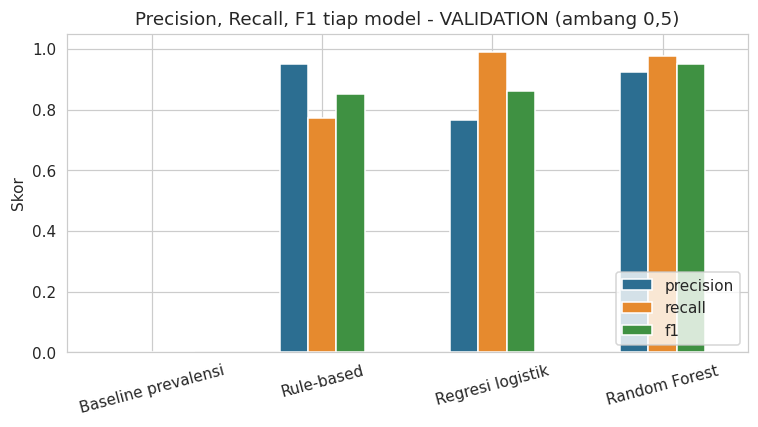

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
metrik_plot = comparison_val[["precision", "recall", "f1"]]
metrik_plot.plot(kind="bar", ax=ax, color=["#2c6e91", "#e68a2e", "#3f9142"])
ax.set_ylim(0, 1.05)
ax.set_title("Precision, Recall, F1 tiap model - VALIDATION (ambang 0,5)")
ax.set_ylabel("Skor")
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Random Forest unggul di semua metrik (F1 0,95, ROC-AUC 0,99). Regresi logistik recall-nya tinggi
(0,99) tapi precision-nya jatuh - banyak alarm palsu. Rule-based precision-nya tertinggi (0,95)
tapi recall-nya kalah jauh (0,77), karena cuma tahu 3 kolam yang historis rawan.

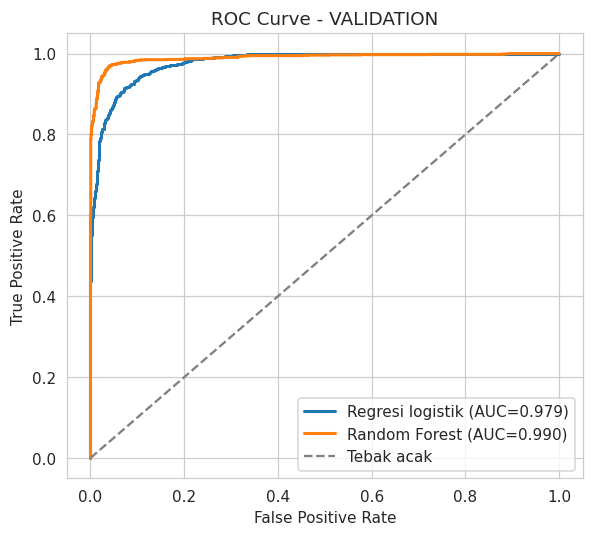

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, proba in [("Regresi logistik", logreg_val_proba), ("Random Forest", rf_val_proba)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Tebak acak")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - VALIDATION")
ax.legend()
plt.tight_layout()
plt.show()

Kurva ROC Random Forest jauh lebih menempel ke pojok kiri-atas dibanding regresi logistik -
konsisten dengan AUC-nya yang lebih tinggi (0,99 vs 0,98).

---
# D. Evaluasi dan Pemilihan Ambang

### D.1 Ambang optimal di VALIDATION (Biaya = 5xFN + 1xFP)

In [12]:
def cost_curve(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        costs.append(5*fn + 1*fp)
    return thresholds, np.array(costs)

t_log, cost_curve_log = cost_curve(y_val, logreg_val_proba)
t_rf, cost_curve_rf = cost_curve(y_val, rf_val_proba)

best_t_log, cost_log = t_log[cost_curve_log.argmin()], cost_curve_log.min()
best_t_rf, cost_rf = t_rf[cost_curve_rf.argmin()], cost_curve_rf.min()

print(f"Regresi logistik - ambang terbaik {best_t_log:.2f}, biaya {cost_log:.0f}")
print(f"Random Forest    - ambang terbaik {best_t_rf:.2f}, biaya {cost_rf:.0f}")

final_model_name = "Random Forest" if cost_rf <= cost_log else "Regresi Logistik"
final_threshold = best_t_rf if cost_rf <= cost_log else best_t_log
final_model = rf if cost_rf <= cost_log else logreg
final_val_proba = rf_val_proba if cost_rf <= cost_log else logreg_val_proba
final_test_proba = rf_test_proba if cost_rf <= cost_log else logreg_test_proba

print(f"\n>> Model terpilih: {final_model_name}, ambang = {final_threshold:.2f}")

Regresi logistik - ambang terbaik 0.61, biaya 523
Random Forest    - ambang terbaik 0.60, biaya 303

>> Model terpilih: Random Forest, ambang = 0.60


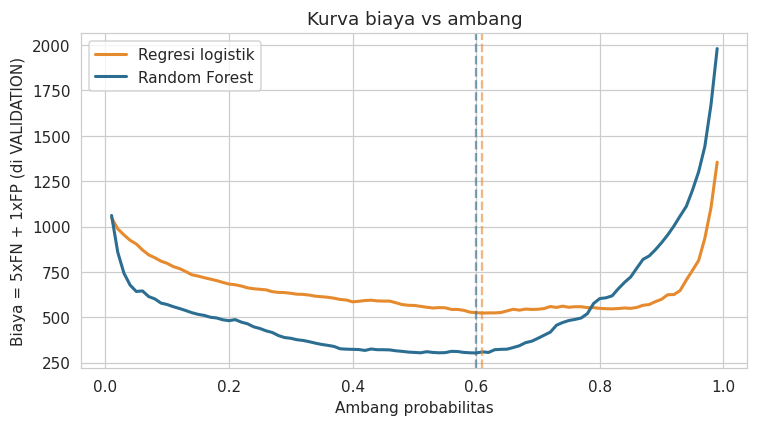

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_log, cost_curve_log, label="Regresi logistik", color="#e68a2e", linewidth=2)
ax.plot(t_rf, cost_curve_rf, label="Random Forest", color="#2c6e91", linewidth=2)
ax.axvline(best_t_rf, color="#2c6e91", linestyle="--", alpha=0.6)
ax.axvline(best_t_log, color="#e68a2e", linestyle="--", alpha=0.6)
ax.set_xlabel("Ambang probabilitas")
ax.set_ylabel("Biaya = 5xFN + 1xFP (di VALIDATION)")
ax.set_title("Kurva biaya vs ambang")
ax.legend()
plt.tight_layout()
plt.show()

Random Forest menang telak dari sisi biaya (303 vs 523), jadi dipakai sebagai model final dengan
ambang 0,60. Kurva birunya juga jauh lebih landai dan rendah dibanding kurva oranye - artinya
Random Forest tidak terlalu sensitif terhadap pemilihan ambang di sekitar titik optimalnya.

### D.2 Evaluasi TEST — satu kali, dengan model dan ambang yang sudah dikunci

In [14]:
test_pred_final = (final_test_proba >= final_threshold).astype(int)
test_metrics = metrics_at(y_test, test_pred_final, final_test_proba)
print(f"Model: {final_model_name} | Ambang: {final_threshold}")
pd.Series(test_metrics).round(4)

Model: Random Forest | Ambang: 0.6


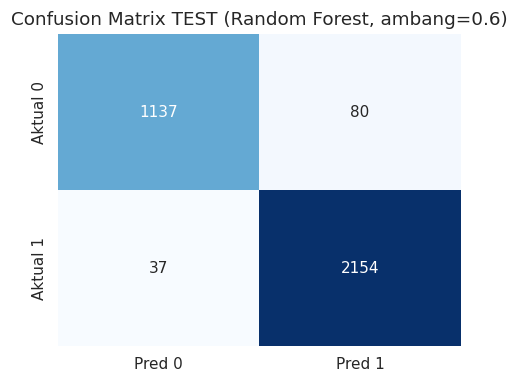

In [15]:
cm = confusion_matrix(y_test, test_pred_final, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Aktual 0", "Aktual 1"], ax=ax)
ax.set_title(f"Confusion Matrix TEST ({final_model_name}, ambang={final_threshold})")
plt.tight_layout()
plt.show()

Dari 3.408 baris TEST cuma 117 yang salah (TN=1137, FP=80, FN=37, TP=2154), recall 0,983 dan
precision 0,964.

### D.3 Pergeseran prevalensi TRAIN -> VALIDATION -> TEST

               prevalensi      n
dataset_split                   
TEST               0.6429   3408
TRAIN              0.0849  16128
VALIDATION         0.4612   3456
Baseline prevalensi - akurasi VALIDATION: 0.5388 | TEST: 0.3571
Rule-based - recall VALIDATION: 0.7729 | TEST: 0.5833


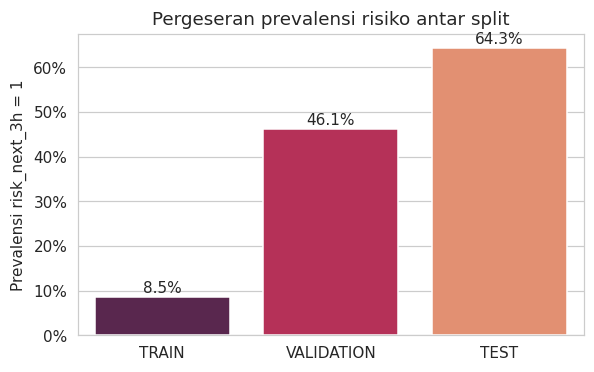

In [16]:
prevalence_summary = df_model.groupby("dataset_split")["risk_next_3h"].agg(["mean", "count"])
prevalence_summary.columns = ["prevalensi", "n"]
print(prevalence_summary.round(4))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
order = ["TRAIN", "VALIDATION", "TEST"]
vals = [prevalence_summary.loc[s, "prevalensi"] for s in order]
sns.barplot(x=order, y=vals, hue=order, palette="rocket", legend=False, ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Prevalensi risk_next_3h = 1")
ax.set_title("Pergeseran prevalensi risiko antar split")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

print("Baseline prevalensi - akurasi VALIDATION:", round(accuracy_score(y_val, base_val_pred), 4),
      "| TEST:", round(accuracy_score(y_test, base_test_pred), 4))
print("Rule-based - recall VALIDATION:", round(recall_score(y_val, rule_val_pred), 4),
      "| TEST:", round(recall_score(y_test, rule_test_pred), 4))

Prevalensinya melonjak dari 8,5% (TRAIN) ke 46% (VALIDATION) ke 64% (TEST) - biomassa terus
bertambah sepanjang 60 hari siklus, dan TEST persis berisi hari-hari terakhir dengan biomassa
tertinggi. Dampaknya kelihatan jelas: baseline prevalensi yang akurasinya 53,9% di VALIDATION
anjlok ke 35,7% di TEST (lebih buruk dari tebak acak) karena kelas mayoritas terbalik. Rule-based
juga recall-nya turun dari 0,77 ke 0,58 karena kolam yang "aman" di TRAIN (P02, P04, P05) ikut
jadi berisiko di periode TEST. Ini yang bikin model bagus di VALIDATION belum tentu sama bagus di
TEST: datanya sendiri bukan i.i.d., distribusinya bergeser seiring waktu.

### D.4 Kinerja per kolam, per sensor_quality_flag, per time_period (TEST)

In [17]:
df_test_full = df_model[split == "TEST"].copy()
df_test_full["y_true"] = y_test.values
df_test_full["y_prob"] = final_test_proba
df_test_full["y_pred"] = test_pred_final
df_test_full["sensor_quality_flag"] = df.loc[df_test_full.index, "sensor_quality_flag"]
df_test_full["pond"] = df.loc[df_test_full.index, pond_cols].idxmax(axis=1).str.replace("pond_", "", regex=False)
tp_cols = [c for c in df.columns if c.startswith("tp_")]
df_test_full["time_period"] = df.loc[df_test_full.index, tp_cols].idxmax(axis=1).str.replace("tp_", "", regex=False)

per_pond = df_test_full.groupby("pond").apply(
    lambda g: pd.Series({
        "n": len(g), "prevalensi": g["y_true"].mean(),
        "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0) if g["y_true"].sum()>0 else np.nan,
        "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
    }), include_groups=False
)
per_pond

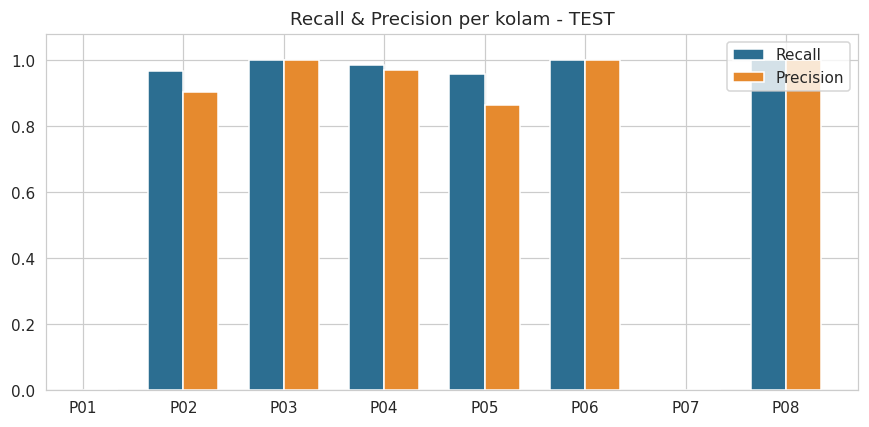

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(per_pond))
w = 0.35
ax.bar(x - w/2, per_pond["recall"], width=w, label="Recall", color="#2c6e91")
ax.bar(x + w/2, per_pond["precision"], width=w, label="Precision", color="#e68a2e")
ax.set_xticks(x); ax.set_xticklabels(per_pond.index)
ax.set_ylim(0, 1.08)
ax.set_title("Recall & Precision per kolam - TEST")
ax.legend()
plt.tight_layout()
plt.show()

Nyaris sempurna di kolam yang "ekstrem" (P01 selalu aman; P03, P06, P08 selalu berisiko), dan
sedikit lebih rendah di kolam "borderline" P02, P04, P05, P07 - detailnya di bagian E.

In [19]:
print("Per sensor_quality_flag:")
for flag, sub in df_test_full.groupby("sensor_quality_flag"):
    prec = precision_score(sub["y_true"], sub["y_pred"], zero_division=0)
    rec = recall_score(sub["y_true"], sub["y_pred"], zero_division=0) if sub["y_true"].sum()>0 else np.nan
    print(f"  {flag:16s} n={len(sub):4d}  prevalensi={sub['y_true'].mean():.3f}  precision={prec:.3f}  recall={rec}")

print("\nPer time_period:")
for tp, sub in df_test_full.groupby("time_period"):
    prec = precision_score(sub["y_true"], sub["y_pred"], zero_division=0)
    rec = recall_score(sub["y_true"], sub["y_pred"], zero_division=0)
    print(f"  {tp:10s} n={len(sub):4d}  prevalensi={sub['y_true'].mean():.3f}  precision={prec:.3f}  recall={rec:.3f}")

Per sensor_quality_flag:
  DO_SPIKE         n=   8  prevalensi=0.875  precision=1.000  recall=1.0
  OK               n=3300  prevalensi=0.634  precision=0.963  recall=0.9823220258002867
  PH_DRIFT         n=  78  prevalensi=1.000  precision=1.000  recall=1.0
  SENSOR_MISSING   n=  22  prevalensi=0.591  precision=1.000  recall=1.0

Per time_period:
  afternoon  n= 864  prevalensi=0.632  precision=0.964  recall=0.989
  dawn       n= 864  prevalensi=0.662  precision=0.961  recall=0.955
  morning    n= 864  prevalensi=0.631  precision=0.940  recall=0.998
  night      n= 816  prevalensi=0.647  precision=0.994  recall=0.992


Baris OK (n=3300) hasilnya sebanding dengan baris berflag DO_SPIKE/PH_DRIFT/SENSOR_MISSING, tapi
baris berflag itu jumlahnya kecil (8-78 baris) jadi belum representatif untuk disimpulkan model
"kebal" terhadap sensor bermasalah. Per time_period, recall paling rendah ada di dawn (0,955)
dibanding jam lain (0,98-0,99) - konsisten dengan pola galat yang dibahas berikutnya.

In [20]:
raw_ids = pd.read_csv(DATA_PATH, usecols=["record_id"])
pred_out = df_model.loc[split == "TEST", ["record_id"]].copy()
pred_out["timestamp"] = df_test_full["timestamp"].values
pred_out["pond_id"] = df_test_full["pond"].values
pred_out["y_true"] = df_test_full["y_true"].values
pred_out["y_prob"] = df_test_full["y_prob"].values
pred_out["y_pred"] = df_test_full["y_pred"].values
pred_out.to_csv("KelompokXX_test_predictions.csv", index=False)
print(pred_out.shape)
pred_out.head()

(3408, 6)


---
# E. Interpretasi dan Rekomendasi

### E.1 Feature importance

In [21]:
importances = final_model.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"fitur": feature_cols, "importance": importances}).sort_values("importance", ascending=False)
imp_df.head(15)

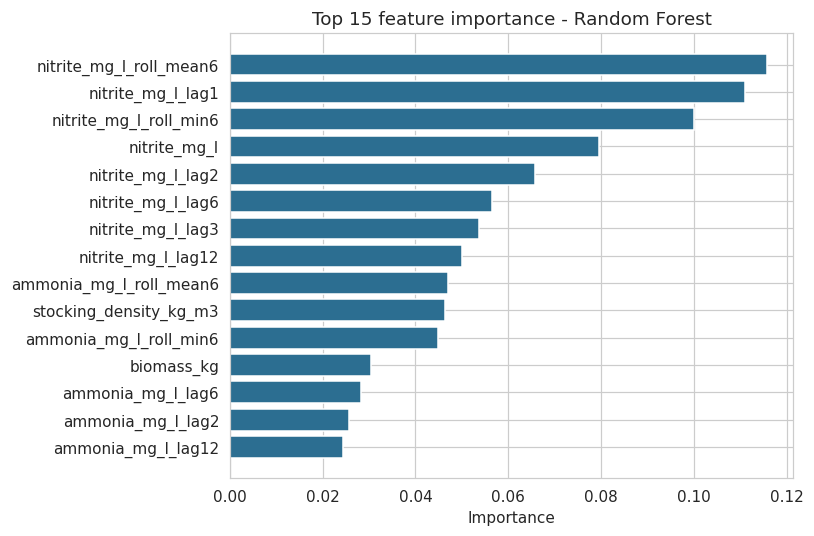

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 5))
top15 = imp_df.head(15).iloc[::-1]
ax.barh(top15["fitur"], top15["importance"], color="#2c6e91")
ax.set_title("Top 15 feature importance - Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Fitur turunan nitrit mendominasi total (5 dari 8 teratas) - wajar karena nitrit salah satu dari
tiga kriteria langsung risiko dan nilainya bergerak lambat/persisten antar interval 30 menit.
Menyusul di bawahnya fitur turunan amonia, lalu `stocking_density_kg_m3` dan `biomass_kg` -
konsisten dengan temuan Diagnostic Minggu 1 bahwa kondisi struktural kolam adalah pendorong
risiko yang kuat.

### E.2 Analisis kesalahan

In [23]:
errors = df_test_full[df_test_full["y_true"] != df_test_full["y_pred"]].copy()
fp = errors[errors["y_pred"] == 1]
fn = errors[errors["y_pred"] == 0]
print(f"Total error: {len(errors)} dari {len(df_test_full)} ({len(errors)/len(df_test_full)*100:.2f}%)")
print(f"False positive: {len(fp)} | False negative: {len(fn)}")
print()
print("Error per kolam:"); print(errors["pond"].value_counts())
print()
print("FN per time_period:"); print(fn["time_period"].value_counts())
print("FP per time_period:"); print(fp["time_period"].value_counts())

Total error: 117 dari 3408 (3.43%)
False positive: 80 | False negative: 37

Error per kolam:
pond
P05    61
P02    26
P04    18
P07    12
Name: count, dtype: int64

FN per time_period:
time_period
dawn         26
afternoon     6
night         4
morning       1
Name: count, dtype: int64
FP per time_period:
time_period
morning      35
dawn         22
afternoon    20
night         3
Name: count, dtype: int64


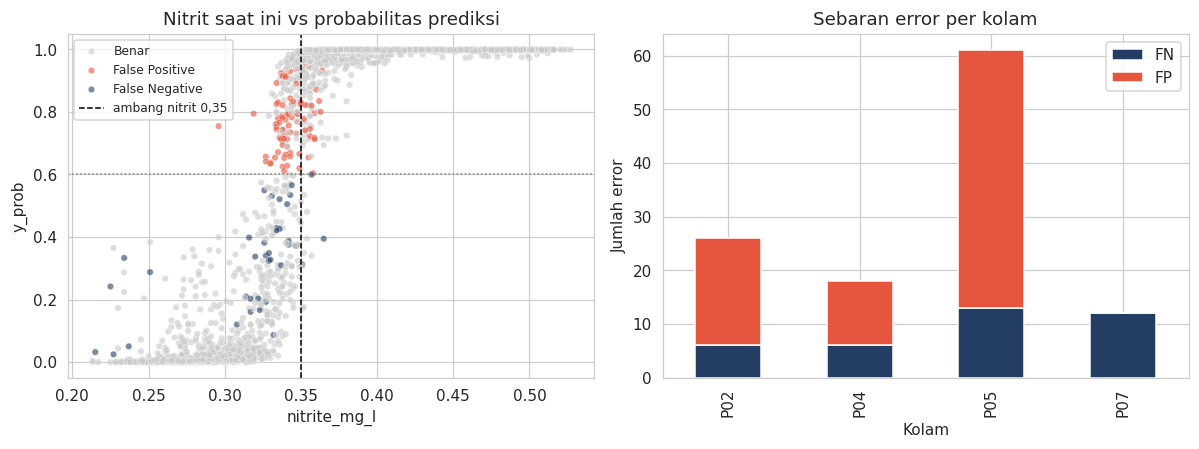

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

correctness = np.where(df_test_full["y_true"]==df_test_full["y_pred"], "Benar",
                np.where(df_test_full["y_pred"]==1, "False Positive", "False Negative"))
sns.scatterplot(data=df_test_full.assign(status=correctness), x="nitrite_mg_l", y="y_prob",
                 hue="status", hue_order=["Benar","False Positive","False Negative"],
                 palette={"Benar":"#c8c8c8","False Positive":"#e6553d","False Negative":"#233d63"},
                 alpha=0.6, s=18, ax=axes[0])
axes[0].axvline(0.35, color="black", linestyle="--", linewidth=1, label="ambang nitrit 0,35")
axes[0].axhline(final_threshold, color="grey", linestyle=":", linewidth=1)
axes[0].set_title("Nitrit saat ini vs probabilitas prediksi")
axes[0].set_xlabel("nitrite_mg_l"); axes[0].set_ylabel("y_prob")
axes[0].legend(fontsize=8)

errors_ct = pd.crosstab(errors["pond"], np.where(errors["y_pred"]==1, "FP", "FN"))
errors_ct.plot(kind="bar", stacked=True, ax=axes[1], color=["#233d63", "#e6553d"])
axes[1].set_title("Sebaran error per kolam")
axes[1].set_xlabel("Kolam"); axes[1].set_ylabel("Jumlah error")
axes[1].legend(title="")
plt.tight_layout()
plt.show()

Error nyaris tidak muncul di kolam ekstrem (P01 yang selalu aman, P03/P06/P08 yang selalu
berisiko) - semuanya terkonsentrasi di kolam "borderline" P02, P04, P05, dan P07, tempat nitrit
sering berada persis di sekitar ambang 0,35 mg/L (kelihatan dari scatter kiri, titik merah dan
biru tua menumpuk di sekitar garis putus-putus).

In [25]:
cols_show = ["pond","time_period","dissolved_oxygen_mg_l","ammonia_mg_l","nitrite_mg_l","y_prob","biomass_kg"]
print("12 false negative dengan probabilitas paling rendah (risiko nyata, hampir tidak terdeteksi):")
print(fn[cols_show].sort_values("y_prob").head(12).to_string(index=False))

12 false negative dengan probabilitas paling rendah (risiko nyata, hampir tidak terdeteksi):
pond time_period  dissolved_oxygen_mg_l  ammonia_mg_l  nitrite_mg_l   y_prob  biomass_kg
 P07        dawn                   4.49         0.301         0.227 0.024734      1385.8
 P07        dawn                   4.24         0.292         0.215 0.031996      1385.8
 P07        dawn                   4.08         0.315         0.237 0.050311      1385.8
 P07        dawn                   4.34         0.353         0.332 0.086590      1433.6
 P07        dawn                   3.93         0.350         0.308 0.119941      1433.6
 P05        dawn                   4.12         0.421         0.317 0.160619      1401.7
 P05        dawn                   3.83         0.403         0.323 0.166412      1401.7
 P05        dawn                   3.98         0.423         0.327 0.192185      1401.7
 P05        dawn                   3.82         0.396         0.317 0.202551      1401.7
 P05        dawn 

In [26]:
print("12 false positive dengan probabilitas paling tinggi (alarm yang ternyata salah):")
print(fp[cols_show].sort_values("y_prob", ascending=False).head(12).to_string(index=False))

12 false positive dengan probabilitas paling tinggi (alarm yang ternyata salah):
pond time_period  dissolved_oxygen_mg_l  ammonia_mg_l  nitrite_mg_l   y_prob  biomass_kg
 P04     morning                   4.96         0.485         0.380 0.991111      1590.3
 P05     morning                   4.94         0.447         0.370 0.978097      1389.9
 P04        dawn                   4.73         0.420         0.344 0.968052      1524.4
 P04     morning                   5.19         0.444         0.351 0.946716      1524.4
 P04        dawn                   4.00         0.417         0.355 0.945289      1524.4
 P04        dawn                   4.05         0.392         0.347 0.935742      1524.4
 P05     morning                   5.32         0.384         0.364 0.931150      1355.0
 P04        dawn                   3.88         0.421         0.343 0.929678      1524.4
 P04        dawn                   4.40         0.418         0.337 0.923846      1524.4
 P04        dawn             

False negative 70%-nya terjadi pada fase dawn, terutama di P07 dan P05: nitrit/DO saat itu ada
tepat di bawah ambang tapi naik melewatinya dalam 3 jam berikutnya, sementara model kelihatan
terlalu percaya prior "P07 umumnya aman" (prevalensi P07 di TRAIN cuma 0,3%). False positive
banyak muncul pagi hari di P04/P05 saat nitrit sudah di atas 0,35 tapi ternyata turun lagi dalam
3 jam berikutnya - menegaskan bahwa target `risk_next_3h` memang ke depan (bukan kondisi saat
ini), jadi kasus yang nilainya persis di sekitar ambang paling sulit ditebak ke dua arah.

### E.3 Usulan Rekomendasi

Berdasar temuan Minggu 1 dan bagian E.1-E.2 di atas, kami usulkan tiga rekomendasi: dua
operasional dan satu pengelolaan sensor.

1. Prioritaskan pemantauan & pertukaran air berdasar kondisi struktural kolam (biomassa/kepadatan), bukan jadwal seragam.
2. Jadikan `aerator_fault` pemicu alert prioritas, terpisah dari status ON/OFF biasa.
3. Kalibrasi ulang berkala untuk sensor pH dan DO, prioritaskan kolam dengan riwayat drift/spike/flatline.

### E.4 Bukti, Manfaat, Risiko, dan Data Tambahan per Rekomendasi

**1. Prioritaskan pemantauan & pertukaran air berdasar kondisi struktural kolam**

- **Bukti pendukung:** risiko berkorelasi sangat kuat dengan biomassa (r=0,94) dan kepadatan tebar (r=0,96) di Diagnostic Minggu 1; `stocking_density_kg_m3` dan `biomass_kg` juga masuk fitur penting model (E.1).
- **Manfaat diharapkan:** sumber daya pemantauan dan jadwal pertukaran air bisa difokuskan ke kolam yang secara struktural rawan, bukan disamaratakan ke semua kolam.
- **Risiko penerapan:** kebijakan berbasis identitas kolam semata bisa lengah kalau kolam yang tadinya aman (P02/P04/P05 di data ini) ikut jadi berisiko seiring waktu (lihat pergeseran prevalensi di D.3) - tetap perlu pemantauan real-time, bukan cuma label statis per kolam.
- **Data tambahan yang diperlukan:** histori lebih dari satu siklus tebar-panen, untuk memastikan pola biomassa-risiko ini konsisten antar siklus, bukan cuma kebetulan di satu siklus 60 hari ini.

**2. Jadikan `aerator_fault` pemicu alert prioritas, terpisah dari status ON/OFF biasa**

- **Bukti pendukung:** DO terendah di Diagnostic Minggu 1 konsisten terjadi tepat saat `aerator_fault=1`, bukan sekadar saat status OFF (yang justru menunjukkan reverse causality kalau dibaca mentah).
- **Manfaat diharapkan:** alert menangani akar masalah (kegagalan alat), bukan status ON/OFF yang bisa menyesatkan.
- **Risiko penerapan:** butuh sensor status aerator yang sendirinya andal (ironisnya sensor juga bisa salah baca, lihat audit data Minggu 1); alert yang terlalu sering berpotensi diabaikan operator (alert fatigue).
- **Data tambahan yang diperlukan:** log pemeliharaan/perbaikan aerator riil dan waktu respons perbaikan, untuk memvalidasi alert ini benar-benar berkaitan dengan kegagalan fisik alat.

**3. Kalibrasi ulang berkala untuk sensor pH dan DO, prioritaskan kolam dengan riwayat drift/spike/flatline**

- **Bukti pendukung:** `PH_DRIFT` dan `DO_SPIKE`/`DO_FLATLINE` terkonsentrasi di kolam tertentu (audit Minggu 1), menandakan masalah alat fisik, bukan pola air yang acak.
- **Manfaat diharapkan:** mengurangi risiko early warning salah baca akibat sensor macet/drift, terutama karena flag ini kadang tumpang tindih dengan kondisi ekstrem yang justru penting dideteksi.
- **Risiko penerapan:** ada biaya kalibrasi/penggantian sensor dan downtime pemantauan selama maintenance berlangsung.
- **Data tambahan yang diperlukan:** histori maintenance/kalibrasi per unit sensor fisik (bukan cuma per kolam), untuk mengonfirmasi sensor mana yang benar-benar bermasalah.

---
Ringkasan: model final Random Forest dengan ambang 0,60 memberi precision 0,964 dan recall
0,983 di TEST. Perlu dicatat performa setinggi ini sebagian besar didorong oleh fitur turunan
nitrit yang memang salah satu penyusun definisi label - jadi hasil ini optimis dibanding kondisi
nyata di mana sensor bisa delay atau gagal baca (lihat audit Minggu 1). Pergeseran prevalensi
antar TRAIN/VALIDATION/TEST juga jadi pengingat bahwa performa ini belum tentu bertahan pada
siklus budidaya berikutnya dengan pola biomassa berbeda.